In [56]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


import joblib


In [57]:
df = pd.read_csv(
    "../data/preprocessed_dataset.csv"
)

df.head()


,Asset_Type,Total_Maintenance_Cost,Condition_Score,Failure_Impact_Score,Failure_History_Count,Operating_Hours,Environmental_Stress_Index,System_Importance_Score,Failure_Probability,Budget_Constraint_Flag,RUL,Days_Since_Maintenance
0,3,45406.15,9.22,4,5,81703,0.99,0.64,0.52,1,5.90,1617
1,2,33701.25,9.58,19,0,42445,0.73,0.59,0.83,1,10.26,2398
2,0,28241.81,3.94,91,6,48636,0.36,0.90,0.82,0,3.08,1557
3,2,5993.98,4.19,45,6,74927,0.70,0.65,0.95,0,0.73,1474
4,2,22629.25,5.55,43,9,79194,0.73,0.35,0.69,0,1.89,2076


In [58]:
X = df[[
    'Asset_Type',
    'Total_Maintenance_Cost',
    'Condition_Score',
    'Failure_Impact_Score',
    'Failure_History_Count',
    'Operating_Hours',
    'Environmental_Stress_Index',
    'System_Importance_Score',
    'Budget_Constraint_Flag',
    'Days_Since_Maintenance',
    'Failure_Probability'
]]

y = df["RUL"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)


In [62]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("\nRANDOM FOREST RESULTS")
print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")


RANDOM FOREST RESULTS
MAE : 0.1724
RMSE: 0.2359
R²  : 0.9958


In [63]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("\nRandom Forest CV Scores:")
print(rf_cv_scores)

print("Average CV Score:", rf_cv_scores.mean())


Random Forest CV Scores:
[0.99357474 0.99321348 0.99438995 0.99458915 0.99487366]
Average CV Score: 0.9941281955700703


                       Feature  Importance
2              Condition_Score    0.546950
5              Operating_Hours    0.447287
9       Days_Since_Maintenance    0.000891
1       Total_Maintenance_Cost    0.000851
7      System_Importance_Score    0.000821
3         Failure_Impact_Score    0.000757
10         Failure_Probability    0.000726
6   Environmental_Stress_Index    0.000649
4        Failure_History_Count    0.000583
0                   Asset_Type    0.000348
8       Budget_Constraint_Flag    0.000137


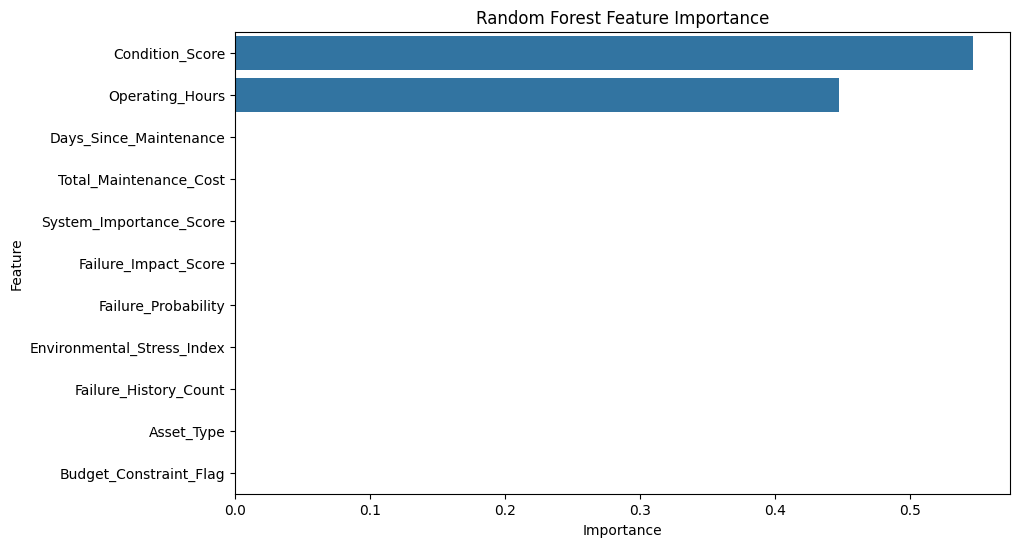

In [64]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

print(rf_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")

plt.show()

In [65]:

joblib.dump(

    rf_model,

    "../models/random_forest.pkl"
)

print("Random Forest Saved")

Random Forest Saved


In [66]:
xgb_model = XGBRegressor(
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

xgb_predictions = xgb_model.predict(
    X_test_scaled
)

In [67]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("\nXGBOOST RESULTS")
print(f"MAE : {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²  : {xgb_r2:.4f}")


XGBOOST RESULTS
MAE : 0.1740
RMSE: 0.2426
R²  : 0.9956


In [68]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='r2'
)

print("\nXGBoost CV Scores:")
print(xgb_cv_scores)

print("Average CV Score:", xgb_cv_scores.mean())


XGBoost CV Scores:
[0.99481507 0.99377194 0.9924571  0.99575064 0.99311063]
Average CV Score: 0.9939810778881906


                       Feature  Importance
2              Condition_Score    0.540492
5              Operating_Hours    0.456990
9       Days_Since_Maintenance    0.000737
4        Failure_History_Count    0.000346
3         Failure_Impact_Score    0.000339
7      System_Importance_Score    0.000246
6   Environmental_Stress_Index    0.000233
1       Total_Maintenance_Cost    0.000221
10         Failure_Probability    0.000149
8       Budget_Constraint_Flag    0.000147
0                   Asset_Type    0.000101


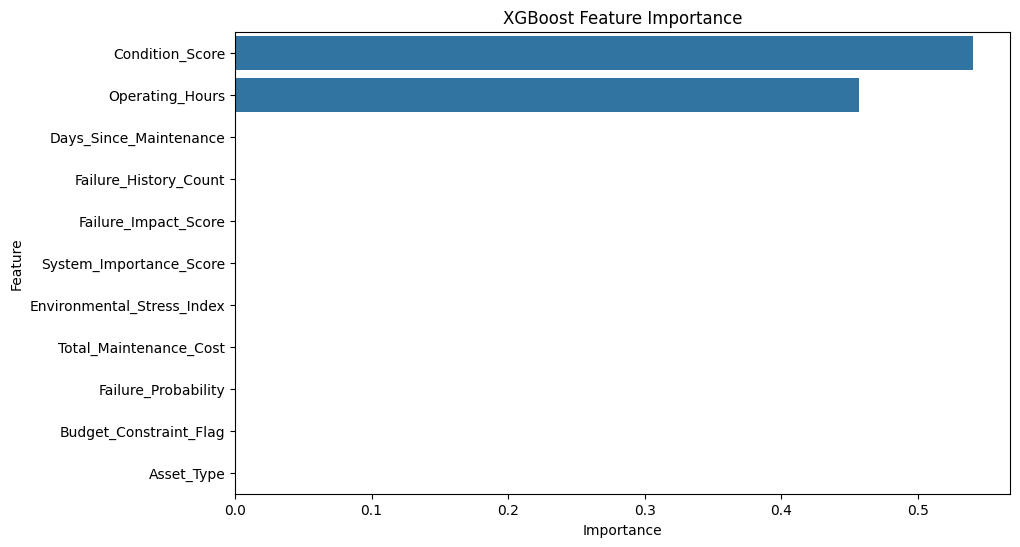

In [69]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

print(xgb_importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance,
    x='Importance',
    y='Feature'
)

plt.title("XGBoost Feature Importance")

plt.show()


In [70]:

joblib.dump(

    xgb_model,

    "../models/xgboost.pkl"
)

print("XGBoost Saved")

XGBoost Saved


In [71]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse
    ],
    "R² Score": [
        rf_r2,
        xgb_r2
    ]
})

print("\nMODEL COMPARISON")
print(comparison)



MODEL COMPARISON
           Model       MAE      RMSE  R² Score
0  Random Forest  0.172446  0.235919  0.995806
1        XGBoost  0.173986  0.242592  0.995566


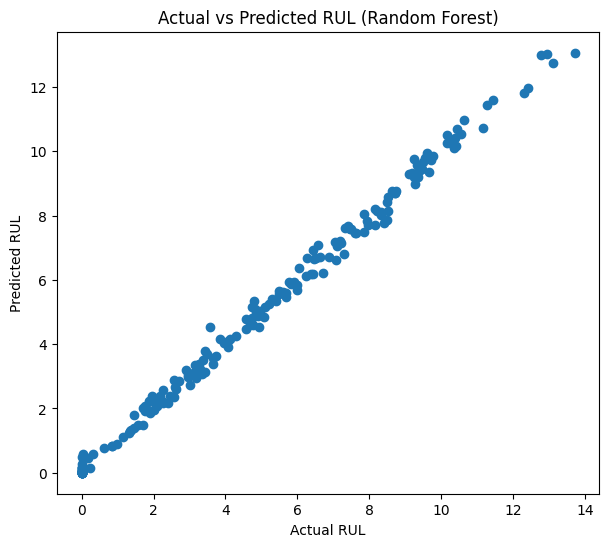

In [72]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Actual vs Predicted RUL (Random Forest)")

plt.show()

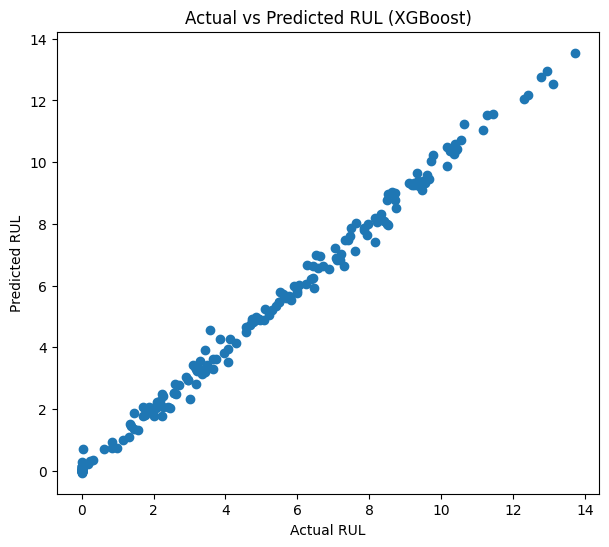

In [73]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    xgb_predictions
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Actual vs Predicted RUL (XGBoost)")

plt.show()